# Maize yield: real data and failed temporal generalization

Compact executed analysis. Paudel/de Wit/Boogaard, Zenodo 7751191, CC BY 4.0. Training code is modular in `src/crop_yield`. Run `python -m crop_yield.cli train` first. This notebook inspects saved evidence; it does not retune using held-out years.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import root_mean_squared_error

root = Path.cwd() if (Path.cwd() / "README.md").exists() else Path.cwd().parent
result = json.loads((root / "reports/metrics.json").read_text())
features = pd.read_csv(root / "data/processed/features.csv")
predictions = pd.read_csv(root / "reports/test_predictions.csv")
print(f"{len(features):,} real county-years; {features.COUNTY_ID.nunique()} counties")
display(
    features.groupby("STATE")
    .agg(
        rows=("YIELD", "size"),
        counties=("COUNTY_ID", "nunique"),
        mean_yield_bu_ac=("YIELD", "mean"),
    )
    .round(2)
)

9,524 real county-years; 528 counties


,rows,counties,mean_yield_bu_ac
STATE,,,
IA,1810,96,167.45
IL,1784,98,160.07
IN,1570,88,154.06
MI,683,38,139.90
MN,322,17,171.01
MO,1254,76,128.77
OH,1350,74,147.81
WI,751,41,144.98


## Source and coverage audit

Join losses are documented, not silently imputed. Complete weather consists of 12 calendar dekads from April through July. No future weather or yield-derived feature enters the tree matrix.

source_yield_rows                                                               45499
source_weather_rows                                                            577980
source_soil_rows                                                                  917
selected_yield_rows                                                             12065
source_zero_yield_rows                                                            501
selected_zero_yield_rows                                                            6
retained_zero_yield_rows                                                            0
dropped_without_soil                                                             2541
dropped_without_complete_weather                                                    0
retained_rows                                                                    9524
counties                                                                          528
states                                               [

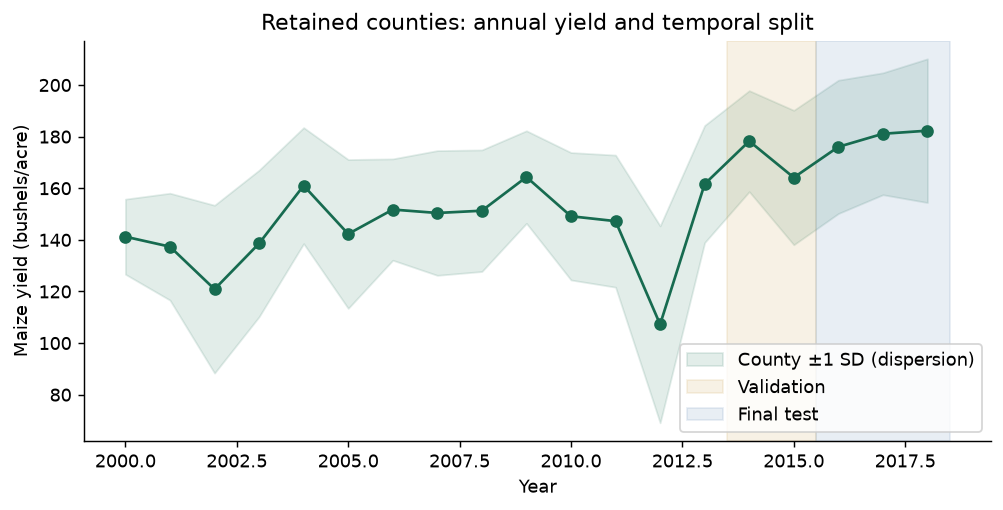

In [2]:
display(pd.Series(result["data_audit"]))
assert len(features) == result["data_audit"]["retained_rows"]
assert not features.duplicated(["COUNTY_ID", "FYEAR"]).any()
assert features.FYEAR.min() == 2000 and features.FYEAR.max() == 2018
display(Image(filename=str(root / "reports/figures/yield-by-year.png")))

## Fixed candidate comparison

Model selection uses only 2014–2015. Candidates are then refit on 2000–2015 and evaluated on 2016–2018. These counties are not geographically independent. RMSE/MAE units: bushels per acre.

In [3]:
validation = pd.DataFrame(result["validation"]).T.add_prefix("validation_")
test_scores = pd.DataFrame(result["test"]).T.add_prefix("test_")
display(validation.join(test_scores).round(3))
selected = min(result["validation"], key=lambda name: result["validation"][name]["rmse"])
assert selected == result["selected_model"]
for name in result["test"]:
    computed = root_mean_squared_error(predictions.YIELD, predictions[name])
    assert np.isclose(computed, result["test"][name]["rmse"], rtol=1e-6)
print("Selected on validation:", selected)
print("Every RMSE recomputed from real held-out predictions.")

,validation_rmse,validation_mae,validation_r2,test_rmse,test_mae,test_r2
global_mean,35.982,31.012,-1.245,41.221,35.160,-1.542
county_trend,34.133,26.862,-1.021,26.787,22.067,-0.073
random_forest,22.898,18.720,0.091,33.514,28.857,-0.680
xgboost,22.877,18.503,0.092,33.213,28.269,-0.650


Selected on validation: xgboost
Every RMSE recomputed from real held-out predictions.


## Generalization failure

XGBoost has negative test R² and underperforms the county-trend baseline. Year dominates its attribution, and trees cannot linearly extrapolate yield growth. This is a plausible explanation, not a causal finding. Do not retune on this already-inspected final test and call it independent.

,dimension,value,n,rmse,mae,r2
0,FYEAR,2016,469,29.321,24.858,-0.291
1,FYEAR,2017,488,34.406,29.131,-1.127
2,FYEAR,2018,434,35.713,30.987,-0.649
3,STATE,IA,278,37.069,34.505,-3.338
4,STATE,IL,265,42.876,37.288,-0.929
5,STATE,IN,234,26.151,22.220,-1.284
6,STATE,MI,101,17.579,13.901,-0.216
7,STATE,MN,50,34.470,31.224,-6.063
8,STATE,MO,149,33.872,29.200,-1.259
9,STATE,OH,204,26.901,21.589,-0.908


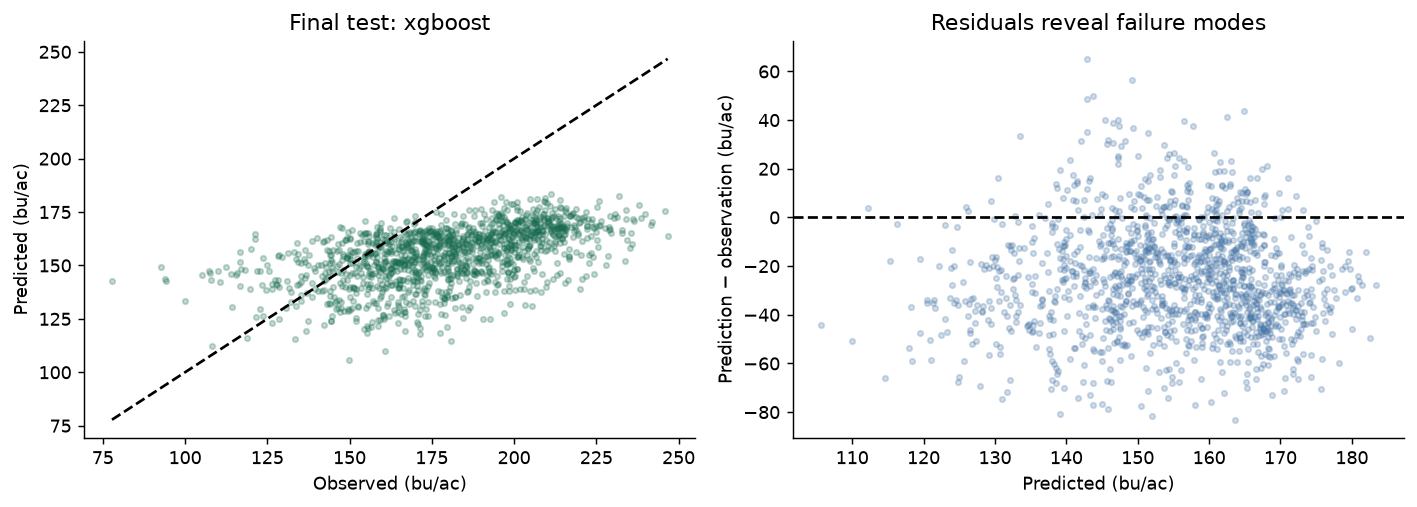

,feature,mean_abs_shap
0,FYEAR,11.689
1,tmin_07,3.569
2,tavg_07,3.194
3,STATE_MO,2.696
4,balance_06,2.396
5,STATE_IL,2.152
6,et0_04,2.148
7,et0_05,1.877
8,SM_WHC,1.784
9,STATE_IA,1.770


Bootstrap caution: Only three test-year clusters; this interval is fragile and descriptive.


In [4]:
display(pd.read_csv(root / "reports/group_metrics.csv").round(3))
display(Image(filename=str(root / "reports/figures/test-diagnostics.png")))
display(pd.read_csv(root / "reports/shap_importance.csv").head(10).round(3))
print("Bootstrap caution:", result["test_rmse_year_bootstrap_95pct"]["warning"])

## Real inference example

No target yield is sent to the predictor. The API validates the same schema and deliberately restricts requests to the historical domain.

In [5]:
from crop_yield.predict import load_artifact, predict_rows

example = json.loads((root / "reports/example-input.json").read_text())
artifact = load_artifact(root / "models/model.joblib")
prediction = predict_rows(artifact, [example])[0]
display(pd.Series(prediction))
assert np.isfinite(prediction["yield_bu_ac"])

county_id                                               IA_ADAIR
year                                                        2016
yield_bu_ac                                           152.565445
model                                                    xgboost
scope          Retrospective US county maize benchmark; no Mo...
dtype: object

## Next research step

Define forward-chaining development folds and training-only yield detrending. Reserve new untouched years or regions. Operational claims additionally require forecast-vintage data and field validation. Implementation and documentation were substantially AI-assisted; learn and defend the method before claiming personal mastery.